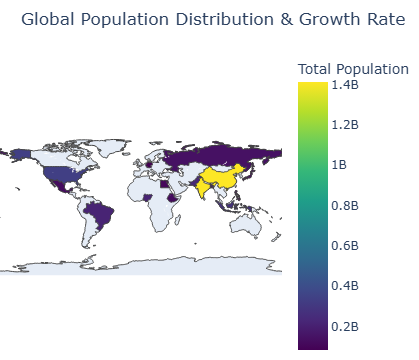

In [4]:
import plotly.express as px
import pandas as pd

# Self-contained global population sample
data = {
    'country': ['China', 'India', 'United States', 'Indonesia', 'Pakistan', 
                'Brazil', 'Nigeria', 'Bangladesh', 'Russia', 'Mexico',
                'Japan', 'Ethiopia', 'Philippines', 'Egypt', 'Germany'],
    'iso_alpha': ['CHN', 'IND', 'USA', 'IDN', 'PAK', 
                  'BRA', 'NGA', 'BGD', 'RUS', 'MEX', 
                  'JPN', 'ETH', 'PHL', 'EGY', 'DEU'],
    'continent': ['Asia', 'Asia', 'Americas', 'Asia', 'Asia', 
                  'Americas', 'Africa', 'Asia', 'Europe', 'Americas', 
                  'Asia', 'Africa', 'Asia', 'Africa', 'Europe'],
    'population': [1412000000, 1408000000, 331900000, 273800000, 231400000,
                   214300000, 213400000, 169400000, 143400000, 126700000,
                   125700000, 120300000, 113900000, 109300000, 83200000],
    'growth_rate': [0.1, 0.8, 0.4, 1.1, 1.9, 0.7, 2.4, 1.0, -0.2, 0.8, -0.5, 2.6, 1.5, 1.7, 0.1]
}
df = pd.DataFrame(data)

fig = px.choropleth(
    df,
    locations='iso_alpha',
    color='population',
    hover_name='country',
    hover_data={'iso_alpha': False, 'continent': True, 'growth_rate': ':.1f%', 'population': ':,d'},
    color_continuous_scale='Viridis',
    title='Global Population Distribution & Growth Rate',
    labels={'population': 'Total Population', 'growth_rate': 'Annual Growth'}
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular'),
    margin=dict(l=0, r=0, t=50, b=0)
)
fig.show()

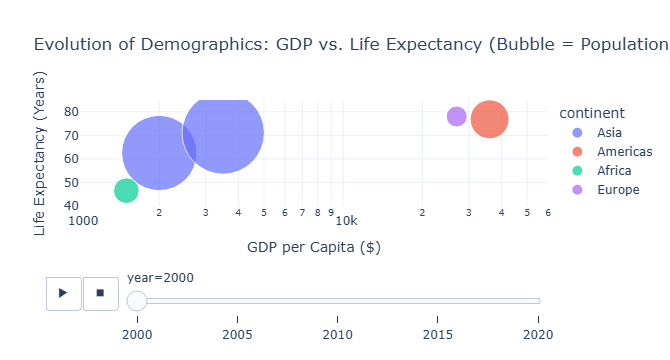

In [2]:
import plotly.express as px
import pandas as pd
import numpy as np

# Synthetic longitudinal demographic panel
years = [2000, 2005, 2010, 2015, 2020]
countries = ['India', 'China', 'United States', 'Nigeria', 'Germany']
records = []

for c in countries:
    base_pop = {'India': 1050, 'China': 1260, 'United States': 282, 'Nigeria': 122, 'Germany': 82}[c]
    base_gdp = {'India': 2000, 'China': 3500, 'United States': 36000, 'Nigeria': 1500, 'Germany': 27000}[c]
    base_life = {'India': 62.5, 'China': 71.0, 'United States': 76.8, 'Nigeria': 46.5, 'Germany': 78.0}[c]
    cont = {'India': 'Asia', 'China': 'Asia', 'United States': 'Americas', 'Nigeria': 'Africa', 'Germany': 'Europe'}[c]
    
    for i, yr in enumerate(years):
        records.append({
            'country': c,
            'continent': cont,
            'year': yr,
            'population': int(base_pop * (1 + 0.015 * i) * 1e6),
            'gdp_per_capita': base_gdp * (1 + 0.05 * i),
            'life_expectancy': base_life + (i * 0.8)
        })

df = pd.DataFrame(records)

fig = px.scatter(
    df,
    x='gdp_per_capita',
    y='life_expectancy',
    animation_frame='year',
    animation_group='country',
    size='population',
    color='continent',
    hover_name='country',
    log_x=True,
    size_max=60,
    range_x=[1000, 60000],
    range_y=[40, 85],
    title='Evolution of Demographics: GDP vs. Life Expectancy (Bubble = Population)',
    labels={'gdp_per_capita': 'GDP per Capita ($)', 'life_expectancy': 'Life Expectancy (Years)'},
    template='plotly_white'
)

fig.show()

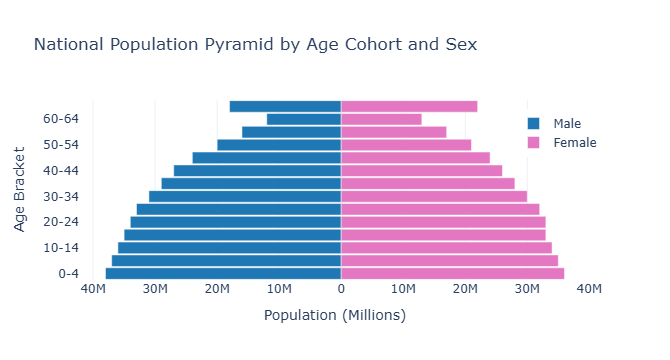

In [3]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

age_groups = ['0-4', '5-9', '10-14', '15-19', '20-24', '25-29', '30-34',
              '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65+']

# Simulated age cohort populations (in millions)
male_pop = np.array([38, 37, 36, 35, 34, 33, 31, 29, 27, 24, 20, 16, 12, 18])
female_pop = np.array([36, 35, 34, 33, 33, 32, 30, 28, 26, 24, 21, 17, 13, 22])

fig = go.Figure()

# Left-side bars: Male (plotted with negative values for orientation)
fig.add_trace(go.Bar(
    y=age_groups,
    x=-male_pop,
    name='Male',
    orientation='h',
    marker=dict(color='#1f77b4'),
    hoverinfo='text',
    hovertext=[f'Age: {ag}<br>Male Pop: {pop}M' for ag, pop in zip(age_groups, male_pop)]
))

# Right-side bars: Female
fig.add_trace(go.Bar(
    y=age_groups,
    x=female_pop,
    name='Female',
    orientation='h',
    marker=dict(color='#e377c2'),
    hoverinfo='text',
    hovertext=[f'Age: {ag}<br>Female Pop: {pop}M' for ag, pop in zip(age_groups, female_pop)]
))

# Configure axes so negative x-values display as positive magnitudes
fig.update_layout(
    title='National Population Pyramid by Age Cohort and Sex',
    barmode='relative',
    bargap=0.1,
    template='plotly_white',
    xaxis=dict(
        tickvals=[-40, -30, -20, -10, 0, 10, 20, 30, 40],
        ticktext=['40M', '30M', '20M', '10M', '0', '10M', '20M', '30M', '40M'],
        title='Population (Millions)'
    ),
    yaxis=dict(title='Age Bracket'),
    legend=dict(x=0.85, y=0.95)
)

fig.show()

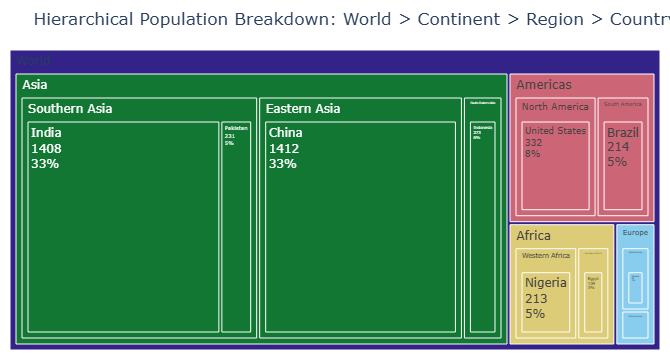

In [4]:
import plotly.express as px
import pandas as pd

data = {
    'continent': ['Asia', 'Asia', 'Asia', 'Asia', 'Europe', 'Europe', 'Americas', 'Americas', 'Africa', 'Africa'],
    'sub_region': ['Eastern Asia', 'Southern Asia', 'South-Eastern Asia', 'Southern Asia',
                  'Western Europe', 'Eastern Europe', 'North America', 'South America',
                  'Western Africa', 'Northern Africa'],
    'country': ['China', 'India', 'Indonesia', 'Pakistan', 'Germany', 'Poland',
                'United States', 'Brazil', 'Nigeria', 'Egypt'],
    'population': [1412, 1408, 273, 231, 83, 38, 332, 214, 213, 109]  # in millions
}
df = pd.DataFrame(data)

fig = px.treemap(
    df,
    path=[px.Constant('World'), 'continent', 'sub_region', 'country'],
    values='population',
    color='continent',
    color_discrete_sequence=px.colors.qualitative.Safe,
    title='Hierarchical Population Breakdown: World > Continent > Region > Country'
)

fig.update_traces(root_color='lightgrey', textinfo='label+value+percent entry')
fig.update_layout(margin=dict(t=50, l=10, r=10, b=10))
fig.show()

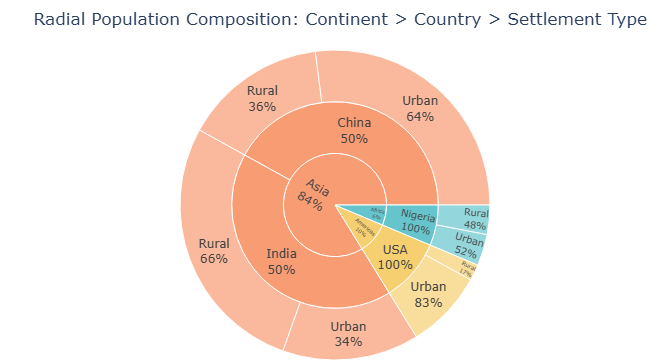

In [2]:
import plotly.express as px
import pandas as pd

# Granular urban/rural breakdown per country
data = {
    'continent': ['Asia', 'Asia', 'Asia', 'Asia', 'Americas', 'Americas', 'Africa', 'Africa'],
    'country': ['India', 'India', 'China', 'China', 'USA', 'USA', 'Nigeria', 'Nigeria'],
    'sector': ['Urban', 'Rural', 'Urban', 'Rural', 'Urban', 'Rural', 'Urban', 'Rural'],
    'population_millions': [480, 928, 910, 502, 275, 57, 110, 103]
}
df = pd.DataFrame(data)

fig = px.sunburst(
    df,
    path=['continent', 'country', 'sector'],
    values='population_millions',
    color='continent',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    title='Radial Population Composition: Continent > Country > Settlement Type',
    template='plotly_white'
)

fig.update_traces(textinfo='label+percent parent')
fig.update_layout(margin=dict(t=50, l=0, r=0, b=0))
fig.show()

In [6]:
pip install dash pandas plotly numpy

  Using cached dash-4.4.1-py3-none-any.whl.metadata (11 kB)
  Using cached retrying-1.4.2-py3-none-any.whl.metadata (5.5 kB)
  Using cached janus-2.0.0-py3-none-any.whl.metadata (5.3 kB)
Using cached dash-4.4.1-py3-none-any.whl (8.9 MB)
Using cached janus-2.0.0-py3-none-any.whl (12 kB)
Using cached retrying-1.4.2-py3-none-any.whl (10 kB)

   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]
   -------------------------- ------------- 2/3 [dash]

In [7]:
import dash
from dash import dcc, html, Input, Output
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. Self-Contained Offline Demographic Dataset
# ---------------------------------------------------------
countries_data = [
    {'country': 'India', 'iso_alpha': 'IND', 'continent': 'Asia', 'population': 1408, 'urban_pct': 35, 'gdp_pc': 2250},
    {'country': 'China', 'iso_alpha': 'CHN', 'continent': 'Asia', 'population': 1412, 'urban_pct': 65, 'gdp_pc': 12500},
    {'country': 'United States', 'iso_alpha': 'USA', 'continent': 'Americas', 'population': 332, 'urban_pct': 83, 'gdp_pc': 70000},
    {'country': 'Nigeria', 'iso_alpha': 'NGA', 'continent': 'Africa', 'population': 213, 'urban_pct': 52, 'gdp_pc': 2100},
    {'country': 'Germany', 'iso_alpha': 'DEU', 'continent': 'Europe', 'population': 83, 'urban_pct': 77, 'gdp_pc': 51000},
    {'country': 'Brazil', 'iso_alpha': 'BRA', 'continent': 'Americas', 'population': 214, 'urban_pct': 87, 'gdp_pc': 8900},
    {'country': 'Japan', 'iso_alpha': 'JPN', 'continent': 'Asia', 'population': 125, 'urban_pct': 92, 'gdp_pc': 39000},
    {'country': 'Egypt', 'iso_alpha': 'EGY', 'continent': 'Africa', 'population': 109, 'urban_pct': 43, 'gdp_pc': 3700}
]
df_countries = pd.DataFrame(countries_data)

age_brackets = ['0-14', '15-29', '30-44', '45-59', '60-74', '75+']

# Simulated age cohort distributions (percentages) per country archetype
def get_pyramid_data(country_name):
    np.random.seed(abs(hash(country_name)) % (10**6))
    base_shares = np.array([0.22, 0.20, 0.20, 0.18, 0.14, 0.06])
    noise = np.random.uniform(0.85, 1.15, size=len(base_shares))
    shares = (base_shares * noise) / np.sum(base_shares * noise)
    
    total_pop = df_countries.loc[df_countries['country'] == country_name, 'population'].values[0]
    bracket_pop = shares * total_pop
    
    males = np.round(bracket_pop * 0.51, 1)
    females = np.round(bracket_pop * 0.49, 1)
    return age_brackets, males, females

# ---------------------------------------------------------
# 2. Dash App Initialization & Layout
# ---------------------------------------------------------
app = dash.Dash(__name__)

app.layout = html.Div(style={'fontFamily': 'system-ui, -apple-system, sans-serif', 'padding': '20px', 'backgroundColor': '#f8f9fa'}, children=[
    html.Div([
        html.H1("Demographic Analytics & Cross-Filter Dashboard", style={'margin': '0 0 8px 0', 'color': '#2c3e50'}),
        html.P("Click any highlighted country on the global map to filter the age pyramid and detailed statistics below.", 
               style={'color': '#7f8c8d', 'margin': '0 0 20px 0'})
    ]),

    # KPI Summary Cards
    html.Div(id='kpi-container', style={'display': 'flex', 'gap': '16px', 'marginBottom': '20px'}),

    # Main Grid: Map & Hierarchy
    html.Div(style={'display': 'grid', 'gridTemplateColumns': '1.2fr 0.8fr', 'gap': '20px', 'marginBottom': '20px'}, children=[
        html.Div(style={'backgroundColor': '#ffffff', 'padding': '16px', 'borderRadius': '8px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.05)'}, children=[
            html.H3("Global Population Distribution (Click a Country)", style={'margin': '0 0 10px 0', 'fontSize': '16px'}),
            dcc.Graph(id='choropleth-map', config={'displayModeBar': False})
        ]),
        html.Div(style={'backgroundColor': '#ffffff', 'padding': '16px', 'borderRadius': '8px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.05)'}, children=[
            html.H3("Regional Composition", style={'margin': '0 0 10px 0', 'fontSize': '16px'}),
            dcc.Graph(id='treemap-chart', config={'displayModeBar': False})
        ])
    ]),

    # Lower Grid: Cross-Filtered Demographic Details
    html.Div(style={'display': 'grid', 'gridTemplateColumns': '1fr 1fr', 'gap': '20px'}, children=[
        html.Div(style={'backgroundColor': '#ffffff', 'padding': '16px', 'borderRadius': '8px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.05)'}, children=[
            html.H3(id='pyramid-title', children="Population Pyramid", style={'margin': '0 0 10px 0', 'fontSize': '16px'}),
            dcc.Graph(id='age-pyramid', config={'displayModeBar': False})
        ]),
        html.Div(style={'backgroundColor': '#ffffff', 'padding': '16px', 'borderRadius': '8px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.05)'}, children=[
            html.H3(id='split-title', children="Urban vs. Rural Distribution", style={'margin': '0 0 10px 0', 'fontSize': '16px'}),
            dcc.Graph(id='donut-chart', config={'displayModeBar': False})
        ])
    ])
])

# ---------------------------------------------------------
# 3. Interactive Callbacks (Cross-Filtering Logic)
# ---------------------------------------------------------
@app.callback(
    [
        Output('choropleth-map', 'figure'),
        Output('treemap-chart', 'figure'),
        Output('age-pyramid', 'figure'),
        Output('donut-chart', 'figure'),
        Output('pyramid-title', 'children'),
        Output('split-title', 'children'),
        Output('kpi-container', 'children')
    ],
    [Input('choropleth-map', 'clickData')]
)
def update_dashboard(click_data):
    # Determine selected country (default: India)
    selected_country = 'India'
    if click_data and 'points' in click_data:
        clicked_iso = click_data['points'][0]['location']
        matched = df_countries[df_countries['iso_alpha'] == clicked_iso]
        if not matched.empty:
            selected_country = matched['country'].values[0]

    # Selected row metadata
    row = df_countries[df_countries['country'] == selected_country].iloc[0]

    # 1. Main Map
    map_fig = px.choropleth(
        df_countries,
        locations='iso_alpha',
        color='population',
        hover_name='country',
        color_continuous_scale='Blues',
        template='plotly_white'
    )
    map_fig.update_geos(showframe=False, showcoastlines=True, projection_type='natural earth')
    map_fig.update_layout(margin=dict(l=0, r=0, t=10, b=0), coloraxis_colorbar=dict(title="Pop (M)"))

    # 2. Treemap Chart
    treemap_fig = px.treemap(
        df_countries,
        path=[px.Constant('World'), 'continent', 'country'],
        values='population',
        color='continent',
        color_discrete_sequence=px.colors.qualitative.Safe,
        template='plotly_white'
    )
    treemap_fig.update_layout(margin=dict(l=0, r=0, t=10, b=0))

    # 3. Cross-Filtered Population Pyramid
    brackets, males, females = get_pyramid_data(selected_country)
    pyramid_fig = go.Figure()
    pyramid_fig.add_trace(go.Bar(
        y=brackets, x=-males, name='Male', orientation='h',
        marker=dict(color='#2b5c8f'),
        hovertext=[f'{m}M' for m in males], hoverinfo='text+y'
    ))
    pyramid_fig.add_trace(go.Bar(
        y=brackets, x=females, name='Female', orientation='h',
        marker=dict(color='#e74c3c'),
        hovertext=[f'{f}M' for f in females], hoverinfo='text+y'
    ))
    max_range = max(np.max(males), np.max(females)) * 1.25
    pyramid_fig.update_layout(
        barmode='relative',
        template='plotly_white',
        margin=dict(l=10, r=10, t=20, b=10),
        xaxis=dict(
            range=[-max_range, max_range],
            tickvals=[-int(max_range/2), 0, int(max_range/2)],
            ticktext=[f'{int(max_range/2)}M', '0', f'{int(max_range/2)}M'],
            title='Population in Millions'
        )
    )

    # 4. Cross-Filtered Donut Chart (Urban vs Rural)
    urban_pop = round(row['population'] * (row['urban_pct'] / 100), 1)
    rural_pop = round(row['population'] - urban_pop, 1)
    donut_fig = go.Figure(data=[go.Pie(
        labels=['Urban', 'Rural'],
        values=[urban_pop, rural_pop],
        hole=0.55,
        marker=dict(colors=['#16a085', '#bdc3c7'])
    )])
    donut_fig.update_layout(margin=dict(l=10, r=10, t=20, b=10), template='plotly_white')

    # 5. KPI Cards Layout
    kpi_cards = [
        html.Div(style={'flex': 1, 'backgroundColor': '#fff', 'padding': '14px', 'borderRadius': '8px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.05)'}, children=[
            html.Span("Selected Country", style={'fontSize': '12px', 'color': '#7f8c8d'}),
            html.H2(selected_country, style={'margin': '4px 0 0 0', 'color': '#2c3e50'})
        ]),
        html.Div(style={'flex': 1, 'backgroundColor': '#fff', 'padding': '14px', 'borderRadius': '8px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.05)'}, children=[
            html.Span("Total Population", style={'fontSize': '12px', 'color': '#7f8c8d'}),
            html.H2(f"{row['population']:,} M", style={'margin': '4px 0 0 0', 'color': '#2980b9'})
        ]),
        html.Div(style={'flex': 1, 'backgroundColor': '#fff', 'padding': '14px', 'borderRadius': '8px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.05)'}, children=[
            html.Span("Urbanization Rate", style={'fontSize': '12px', 'color': '#7f8c8d'}),
            html.H2(f"{row['urban_pct']}%", style={'margin': '4px 0 0 0', 'color': '#27ae60'})
        ]),
        html.Div(style={'flex': 1, 'backgroundColor': '#fff', 'padding': '14px', 'borderRadius': '8px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.05)'}, children=[
            html.Span("GDP Per Capita", style={'fontSize': '12px', 'color': '#7f8c8d'}),
            html.H2(f"${row['gdp_pc']:,}", style={'margin': '4px 0 0 0', 'color': '#8e44ad'})
        ]),
    ]

    pyramid_heading = f"Age & Gender Pyramid: {selected_country}"
    donut_heading = f"Urban vs. Rural Split: {selected_country}"

    return map_fig, treemap_fig, pyramid_fig, donut_fig, pyramid_heading, donut_heading, kpi_cards

# ---------------------------------------------------------
# 4. Entry Point
# ---------------------------------------------------------
if __name__ == '__main__':
    app.run(debug=True)